Note: this nootbook if for preforming BERTTOpic clustering when the data is too much big to fit in memory leading to Oout of memory (OOM). The nootbook dideivde the data to chunks and  fit a sepreate berttopic model on eeach of the cunnkks. 

# Imports

In [8]:
# ML
import pandas as pd
import numpy as np
import pyarrow  # ensures pandas can read/write parquet
import math

# Models
from bertopic import BERTopic
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import torch

# System
import gc
from pathlib import Path
from datetime import datetime

# import subprocess
import sys
import fcntl
import tempfile
import os


# Pyton
from functools import wraps
from typing import Iterator, List, Tuple

# Visualization
import matplotlib.pyplot as plt
from IPython.display import display
from pprint import pprint
import matplotlib.ticker as ticker

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Parameters

In [ ]:
country="UAE"
input_data_path = f"../results/Labeled_Datasets/{country}/{country}_part_all/step_1_translate_topics_entities/{country}_part_all_step_1.gzip.parquet"
min_topic_size = 2**8
chunk_size = 2**17
is_test = False

if not is_test:
    print(f"Input data path: {input_data_path}")
    print(f"Minimum topic size: {min_topic_size}")
    print(f"Chunk size: {chunk_size:,}")

In [11]:
if is_test:
    print("Running in test mode. Only a small subset of the data will be processed.")
    min_topic_size = 10
    chunk_size = 2**7
    print(f"min_topic_size = {min_topic_size}, chunk_size = {chunk_size}")

Running in test mode. Only a small subset of the data will be processed.
min_topic_size = 10, chunk_size = 128


# Loading and Exporting


In [12]:
from pathlib import Path


def get_dataset_part_path(path: str | Path) -> Path:
    """Return the dataset-part directory containing a pipeline step.

    Args:
        path: Input file or directory inside a ``step_*`` directory.

    Returns:
        Parent directory of the nearest ``step_*`` ancestor.

    Raises:
        ValueError: If the path is not inside a pipeline step directory.
    """
    input_path = Path(path).expanduser()
    for candidate in (input_path, *input_path.parents):
        if candidate.name.startswith("step_"):
            return candidate.parent
    raise ValueError("input_data_path must be inside a step_* directory")

In [13]:
input_data_path = Path(input_data_path).expanduser()
topic_col = f"BERTopic_topic_{min_topic_size}"
topic_top_words_col = f"{topic_col}_top_words"
dataset_part_path = get_dataset_part_path(input_data_path)
dataset_part = dataset_part_path.name
output_path = dataset_part_path / "step_2_big_data_clustering"
if is_test:
    output_path = output_path / "test"
output_path = output_path / f"topic_col_{topic_col}"
output_path.mkdir(parents=True, exist_ok=True)
output_data_path = output_path.parent / f"{dataset_part}_step_2.gzip.parquet"

print(f"Input data path: {input_data_path}")
print(f"Output path: {output_path}")
print(f"Output data path: {output_data_path}")

Input data path: ../results/Labeled_Datasets/UAE/UAE_part_all/step_1_translate_topics_entities/UAE_part_all_step_1.gzip.parquet
Output path: ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/topic_col_BERTopic_topic_10
Output data path: ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/UAE_part_all_step_2.gzip.parquet


In [14]:
import pyarrow.parquet as pq

if is_test:
    parquet_file = pq.ParquetFile(input_data_path)

    batch = next(
        parquet_file.iter_batches(batch_size=1000)
    )

    df = batch.to_pandas().head(1000)
else:
    df = pd.read_parquet(input_data_path)

In [15]:
print(f"df shape: {df.shape}")
print("df columns:")
pprint(list(df.columns))

df shape: (1000, 32)
df columns:
['postid',
 'post_text',
 'application_name',
 'post_language',
 'in_reply_to_postid',
 'in_reply_to_accountid',
 'post_time',
 'accountid',
 'account_profile_description',
 'follower_count',
 'following_count',
 'account_creation_date',
 'is_repost',
 'reposted_accountid',
 'reposted_postid',
 'hashtags',
 'urls',
 'account_mentions',
 'is_control',
 'clean_text_with_entities',
 'clean_text_without_enteties',
 'text_len',
 'translated_post',
 'ner_entities',
 'hashtags_reuse_12H_accountids',
 'account_mentions_reuse_12H_accountids',
 'urls_reuse_12H_accountids',
 'ner_entities_reuse_12H_accountids',
 'hashtags_reuse_3D_accountids',
 'account_mentions_reuse_3D_accountids',
 'urls_reuse_3D_accountids',
 'ner_entities_reuse_3D_accountids']


In [16]:
display(df.head())

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,...,translated_post,ner_entities,hashtags_reuse_12H_accountids,account_mentions_reuse_12H_accountids,urls_reuse_12H_accountids,ner_entities_reuse_12H_accountids,hashtags_reuse_3D_accountids,account_mentions_reuse_3D_accountids,urls_reuse_3D_accountids,ner_entities_reuse_3D_accountids
0,47666930dfeab259ef7700f85c39af9dab00180c23,انا أبريلى,2727201c363b6fc4afe259ba4094ae0c49cb4df224,arb_Arab,None,None,2011-07-23 03:21:00,c477414673d6138962148ba5270c86816ea3bc0efb,‏وها أنا.. أقوم بعدل سنيني المايلة 👌 💪 ✊\n‏‏‏‏...,1005,...,'m april .,[],[],[],[],[],[],[],[],[]
1,fac51aec111c3abe14a7696f12db212933cc7d2a56,كفايه مهانه يا مصرى وثووور .. وأرفض تطاطى وطول...,2727201c363b6fc4afe259ba4094ae0c49cb4df224,arb_Arab,None,None,2011-07-24 23:21:00,c477414673d6138962148ba5270c86816ea3bc0efb,‏وها أنا.. أقوم بعدل سنيني المايلة 👌 💪 ✊\n‏‏‏‏...,1005,...,"enough insulting , egyptian taurus , refusing ...",[egyptian_taurus],[],[],[],[],[],[],[],[]
2,6a6ee0122738e5123a6c071df94b5d3633f14dfcf5,لماذا يريد المجلس العسكرى أن نغضب ؟؟,2727201c363b6fc4afe259ba4094ae0c49cb4df224,arb_Arab,None,None,2011-07-25 05:26:00,c477414673d6138962148ba5270c86816ea3bc0efb,‏وها أنا.. أقوم بعدل سنيني المايلة 👌 💪 ✊\n‏‏‏‏...,1005,...,military council us angry ?,[],[],[],[],[],[],[],[],[]
3,9b72c3633550825f5e3081ed3dc7ce1d7406777395,وأنت بتتفرج على محاكمة العادلى على التليفزيون ...,2727201c363b6fc4afe259ba4094ae0c49cb4df224,arb_Arab,None,None,2011-07-25 05:28:00,c477414673d6138962148ba5270c86816ea3bc0efb,‏وها أنا.. أقوم بعدل سنيني المايلة 👌 💪 ✊\n‏‏‏‏...,1005,...,"'re watching fair trial tv right , protesters ...",[],[],[],[],[],[],[],[],[]
4,bb6d27712f661d71b2a0e7721698c9ba350c8c9e31,نيويورك تايمز: الإخوان سلاح العسكر ضد الثوار |...,2727201c363b6fc4afe259ba4094ae0c49cb4df224,arb_Arab,None,None,2011-07-27 15:27:00,c477414673d6138962148ba5270c86816ea3bc0efb,‏وها أنا.. أقوم بعدل سنيني المايلة 👌 💪 ✊\n‏‏‏‏...,1005,...,brotherhood military weapon rebels.,[],[],[],[],[],[],[],[],[]


# Utils

## Logs

In [17]:
REPORT_PATH = output_path / "progress_report.txt"

def write_report(msg: str):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"{timestamp} | {msg}"

    print(line)
    with open(REPORT_PATH, "a") as f:
        f.write(line + "\n")


write_report(f"Input data path: {input_data_path}")
write_report(f"Output path: {output_path}")

def report_done(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        try:
            result = func(*args, **kwargs)
            write_report(f"Completed: {func.__name__}")
            return result
        except Exception as e:
            write_report(f"FAILED: {func.__name__} | {e}")
            raise
    return wrapper

2026-07-21 15:34:08 | Input data path: ../results/Labeled_Datasets/UAE/UAE_part_all/step_1_translate_topics_entities/UAE_part_all_step_1.gzip.parquet
2026-07-21 15:34:08 | Output path: ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/topic_col_BERTopic_topic_10


In [18]:
write_report(" ############# running: big_data_topic_clustering.ipynb ############# ")
write_report(f"Today date: {datetime.now().strftime('%Y-%m-%d')}")
write_report(f"Input data path: {input_data_path}")
write_report(f"Output path: {output_path}")
write_report(f"Loaded df: {input_data_path.name}.")
write_report(f"df shape: {df.shape}")
write_report(f"min_topic_size: {min_topic_size}")
print("df head:")
display(df.head(3))

2026-07-21 15:34:08 |  ############# running: big_data_topic_clustering.ipynb ############# 
2026-07-21 15:34:08 | Today date: 2026-07-21
2026-07-21 15:34:08 | Input data path: ../results/Labeled_Datasets/UAE/UAE_part_all/step_1_translate_topics_entities/UAE_part_all_step_1.gzip.parquet
2026-07-21 15:34:08 | Output path: ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/topic_col_BERTopic_topic_10
2026-07-21 15:34:08 | Loaded df: UAE_part_all_step_1.gzip.parquet.
2026-07-21 15:34:08 | df shape: (1000, 32)
2026-07-21 15:34:08 | min_topic_size: 10
df head:


,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,...,translated_post,ner_entities,hashtags_reuse_12H_accountids,account_mentions_reuse_12H_accountids,urls_reuse_12H_accountids,ner_entities_reuse_12H_accountids,hashtags_reuse_3D_accountids,account_mentions_reuse_3D_accountids,urls_reuse_3D_accountids,ner_entities_reuse_3D_accountids
0,47666930dfeab259ef7700f85c39af9dab00180c23,انا أبريلى,2727201c363b6fc4afe259ba4094ae0c49cb4df224,arb_Arab,None,None,2011-07-23 03:21:00,c477414673d6138962148ba5270c86816ea3bc0efb,‏وها أنا.. أقوم بعدل سنيني المايلة 👌 💪 ✊\n‏‏‏‏...,1005,...,'m april .,[],[],[],[],[],[],[],[],[]
1,fac51aec111c3abe14a7696f12db212933cc7d2a56,كفايه مهانه يا مصرى وثووور .. وأرفض تطاطى وطول...,2727201c363b6fc4afe259ba4094ae0c49cb4df224,arb_Arab,None,None,2011-07-24 23:21:00,c477414673d6138962148ba5270c86816ea3bc0efb,‏وها أنا.. أقوم بعدل سنيني المايلة 👌 💪 ✊\n‏‏‏‏...,1005,...,"enough insulting , egyptian taurus , refusing ...",[egyptian_taurus],[],[],[],[],[],[],[],[]
2,6a6ee0122738e5123a6c071df94b5d3633f14dfcf5,لماذا يريد المجلس العسكرى أن نغضب ؟؟,2727201c363b6fc4afe259ba4094ae0c49cb4df224,arb_Arab,None,None,2011-07-25 05:26:00,c477414673d6138962148ba5270c86816ea3bc0efb,‏وها أنا.. أقوم بعدل سنيني المايلة 👌 💪 ✊\n‏‏‏‏...,1005,...,military council us angry ?,[],[],[],[],[],[],[],[],[]


## Save/Update df

In [19]:
# @report_done
# def save_df(
#         df: pd.DataFrame,
#         output_data_path: Path = output_data_path
#     )-> None :
#     df.to_parquet(output_data_path, index=False, compression="gzip")
#     write_report(f"df is saved to: {output_data_path}")

In [20]:
from __future__ import annotations

@report_done
def update_df_collumns_atomically(
    df: pd.DataFrame,
    collums_to_update: str | list[str],
    output_data_path: Path = output_data_path,
    compression: str = "gzip",
) -> pd.DataFrame:
    """Safely update or add columns in a shared Parquet file.
    This assumes the same row order/length in df and df_from_file. 

    Performs a transaction-style update:
    exclusive lock -> read latest -> update columns -> write temp -> os.replace.

    Args:
        df: DataFrame containing the new column values.
        collums_to_update: Column name or list of column names to update/add.
        output_data_path: Directory containing the Parquet file.
        compression: Parquet compression codec. Default is "gzip".

    Returns:
        The updated DataFrame that was written to disk.

    Raises:
        RuntimeError: If reading, updating, or writing fails. Original exception
            is attached as context.
    """

    write_report(f"[update_df_collumns_atomically]\n Updating columns: {collums_to_update} \nfrom df to {output_data_path}")
    lock_path = output_data_path.with_suffix(output_data_path.suffix + ".lock")

    if isinstance(collums_to_update, str):
        collums_to_update = [collums_to_update]

    tmp_path: Path | None = None

    with open(lock_path, "w") as lockf:
        fcntl.flock(lockf, fcntl.LOCK_EX)
        try:
            if not output_data_path.exists():
                df_from_file = df.copy()
            else:
                df_from_file = pd.read_parquet(output_data_path)

            for col in collums_to_update:
                df_from_file[col] = df[col]

            fd, tmp = tempfile.mkstemp(
                dir=str(output_data_path.parent),
                prefix=output_data_path.name + ".",
                suffix=".tmp",
            )
            os.close(fd)
            tmp_path = Path(tmp)

            df_from_file.to_parquet(tmp_path, index=False, compression=compression)
            os.replace(tmp_path, output_data_path)

            write_report("[update_df_collumns_atomically]\n Updated columns: " + ", ".join(collums_to_update) + f" \nsave to {output_data_path}")

            return df_from_file

        except Exception as e:
            raise RuntimeError(f"Failed to update parquet file: {output_data_path}") from e

        finally:
            if tmp_path is not None and tmp_path.exists():
                tmp_path.unlink(missing_ok=True)
            fcntl.flock(lockf, fcntl.LOCK_UN)

# Posting Same Topic

In [21]:
time_windows = ["12H", "3D"]

In [22]:
from collections import defaultdict, deque

@report_done
def add_posting_same_topic(
    df: pd.DataFrame,
    topic_column: str,
    time_window: str = "3D",
    account_id_column: str = "accountid",
    timestamp_column: str = "post_time",
) -> str:
    """Add prior authors posting the same topic within a time window.

    The DataFrame is modified in place. Author IDs are unique and ordered by
    the timestamps of their matching posts, from oldest to newest.

    Returns:
        Name of the added account-ID column.
    """
    required_columns = {topic_column, account_id_column, timestamp_column}
    missing_columns = sorted(required_columns - set(df.columns))
    if missing_columns:
        raise KeyError(f"Missing required columns: {missing_columns}")

    output_column = f"posting_same_topic_{topic_column}_{time_window}_accountids"
    timestamps = pd.to_datetime(df[timestamp_column], errors="coerce").to_numpy(
        dtype="datetime64[ns]"
    )
    topics = df[topic_column].to_numpy()
    account_ids = df[account_id_column].to_numpy()
    window_delta = np.timedelta64(pd.Timedelta(time_window).value, "ns")

    output_account_ids = [[] for _ in range(len(df))]
    topic_history: dict[object, deque] = defaultdict(deque)

    for current_index in np.argsort(timestamps, kind="stable"):
        current_timestamp = timestamps[current_index]
        current_topic = topics[current_index]
        if np.isnat(current_timestamp) or pd.isna(current_topic):
            continue

        topic_posts = topic_history[current_topic]
        while topic_posts and current_timestamp - topic_posts[0][0] > window_delta:
            topic_posts.popleft()

        output_account_ids[current_index] = list(
            dict.fromkeys(account_ids[post_index] for _, post_index in topic_posts)
        )
        topic_posts.append((current_timestamp, current_index))

    df[output_column] = output_account_ids
    write_report(
        f"[add_posting_same_topic] Added {output_column} for topic column "
        f"{topic_column} and time window {time_window}."
    )
    return output_column

In [23]:
# Called after BERTopic creates the topic column.

# BERT English Topic Clustering

Note: the topic clustering doent influenced by the entities since it is preformed on the text without the entitites.

## Utils

### Posts Topic Stats

In [24]:
@report_done
def make_topic_stats(df, topic_col_name):
    """
    Calculate per-topic post counts.

    Args:
        df (pd.DataFrame): Data with topics and 'is_control'.
        topic_col_name (str): Column name of topic labels.

    Returns:
        topic_stats (pd.DataFrame): Colums: [topic, total_count, io_Count, legitimate_posts, io_percent].
    """
    topic_stats = (
        df.groupby(topic_col_name)
          .agg(
              total_count=(topic_col_name, "count"),
              io_count=("is_control", lambda x: (~x).sum())
          )
          .reset_index()
    )
    topic_stats["legitimate_posts"] = topic_stats["total_count"] - topic_stats["io_count"]
    topic_stats["io_percent"] = topic_stats["io_count"] / topic_stats["total_count"] * 100
    return topic_stats

In [25]:
from matplotlib.lines import Line2D

def plot_topic_stats(topic_stats, topic_col_name, output_path: str | Path = ""):
    """
    Plot stacked IO vs legitimate post counts per topic.
    Saves the fig to output_path if provided.

    Args:
        topic_stats (pd.DataFrame): Output of make_topic_stats().
        topic_col_name (str): Topic column to plot.
        output_path (str): Path to *folder* save the plot.

    Returns:
        None
    """
    topics = topic_stats[topic_col_name]
    io_count = topic_stats["io_count"]
    legitimate_count = topic_stats["legitimate_posts"]
    io_percent = topic_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO posts
    bar_io = plt.bar(topics, io_count, label="IO posts", color="red")

    # 🔵 Top: Non-IO posts stacked above IO
    bar_legit = plt.bar(topics, legitimate_count, bottom=io_count, label="Non-IO posts")

    # Add IO percentage text
    ax = plt.gca()
    for x, io, legit, pct in zip(topics, io_count, legitimate_count, io_percent):
        total_height = io + legit
        ax.text(
            x,
            total_height + 0.5,              # slightly above the bar
            f"{pct:.1f}%",                 # format like 23.5%
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="regular"
        )

    plt.title(f"Post Count per Topic ({topic_col_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Posts")
    plt.xticks(topics)
    plt.grid(axis="y")
    plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    percent_legend = Line2D([], [], color="none")
    total_posts_legend = Line2D([], [], color="none")
    
    plt.legend(
        handles=[bar_io, bar_legit, percent_legend, total_posts_legend],
        labels=[
            "IO posts",
            "Non-IO posts",
            "% IO Posts Ratio",
            f"Total posts: {topic_stats['total_count'].sum():,}",
        ],
        loc="best",
    )


    plt.tight_layout()


    if output_path:
        output_path = Path(output_path)
        plot_file_path = output_path / (f"{topic_col_name}_topic_clustering.png")
        plt.savefig(plot_file_path, dpi=300)
        print(f"plot is saved to {plot_file_path}")

    plt.show()

    plt.close()

### Accoutns Topic Stats

In [26]:
@report_done
def make_topic_account_stats(
    df: pd.DataFrame,
    topic_col: str,
    author_col: str = "accountid",
    is_control_col: str = "is_control",
    threshold: float = 0.5,
) -> pd.DataFrame:
    """Compute per-topic unique account counts (IO vs control) using an author-level threshold.

    Args:
        df: Post-level DataFrame.
        topic_col: Topic column name.
        author_col: Author identifier column.
        is_control_col: Column where 1 = control, 0 = IO.
        threshold: IO-rate threshold to label an author as IO (1 = IO).

    Returns:
        DataFrame with per-topic counts of unique IO/control accounts and IO percentage.
    """
    # Author-level IO rate: 1 - mean(is_control)
    author_io_rate = 1 - df.groupby(author_col)[is_control_col].mean()
    author_io_tag = (author_io_rate >= threshold).astype(int)

    topic_author_df = df[[topic_col, author_col]].drop_duplicates().copy()
    topic_author_df["author_io_tag"] = topic_author_df[author_col].map(author_io_tag)

    stats = (
        topic_author_df
        .groupby(topic_col)["author_io_tag"]
        .value_counts()
        .unstack(fill_value=0)
    )

    # Ensure both columns exist even if absent in data
    stats = stats.reindex(columns=[0, 1], fill_value=0).rename(
        columns={0: "control_accounts", 1: "io_accounts"}
    ).reset_index()

    stats["total_accounts"] = stats["control_accounts"] + stats["io_accounts"]
    stats["io_percent"] = (stats["io_accounts"] / stats["total_accounts"]).mul(100)

    return stats

In [27]:
def plot_topic_account_stats(
    topic_account_stats: pd.DataFrame,
    topic_col_name: str,
    output_path: Path | str | None = None,
):
    """Plot IO vs control account counts per topic.

    Args:
        topic_account_stats: Output of make_topic_account_stats().
        topic_col_name: Topic column name.
        output_path: Optional folder to save the plot.

    Returns:
        None
    """
    topics = topic_account_stats[topic_col_name]
    io_count = topic_account_stats["io_accounts"]
    control_count = topic_account_stats["control_accounts"]
    io_percent = topic_account_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO accounts
    bar_io = plt.bar(topics, io_count, label="IO accounts", color="red")

    # 🔵 Top: Control accounts
    bar_control = plt.bar(
        topics,
        control_count,
        bottom=io_count,
        label="Control accounts",
    )

    # Add IO percentage text
    ax = plt.gca()
    for x, io, ctrl, pct in zip(topics, io_count, control_count, io_percent):
        total = io + ctrl
        ax.text(
            x,
            total + 0.3,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="regular",
        )

    plt.title(f"Unique Accounts per Topic ({topic_col_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Unique Accounts")
    plt.xticks(topics)
    plt.grid(axis="y")
    plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    
    # Legend with extra info lines
    percent_legend = Line2D([], [], color="none")
    total_accounts_legend = Line2D([], [], color="none")

    plt.legend(
        handles=[bar_io, bar_control, percent_legend, total_accounts_legend],
        labels=[
            "IO accounts",
            "Control accounts",
            "% IO Accounts Ratio",
            f"Total accounts: {topic_account_stats['total_accounts'].sum():,}",
        ],
        loc="best",
    )

    if output_path:
        output_path = Path(output_path)
        plot_file_path = output_path / f"{topic_col_name}_topic_accounts.png"
        plt.savefig(plot_file_path, dpi=300)
        print(f"Plot saved to {plot_file_path}")

    plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    plt.show()
    plt.close()

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Embeddings

In [29]:
from sentence_transformers import SentenceTransformer

post_text_col = "translated_post"

posts_texts = df[post_text_col].astype(str).tolist()

model = SentenceTransformer("digio/Twitter4SSE", device=device)
write_report(f"Embeddings Model loaded: {model.__class__.__name__} on device {device}")

embeddings = model.encode(
    posts_texts,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True, 
)

embeddings = np.ascontiguousarray(embeddings, dtype=np.float32)
write_report(f"Generated embeddings shape: {embeddings.shape}")

2026-07-21 15:34:11 | Embeddings Model loaded: SentenceTransformer on device cuda


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2026-07-21 15:34:12 | Generated embeddings shape: (1000, 768)


## BERTopic

[BERTopic Parametes](https://maartengr.github.io/BERTopic/getting_started/parameter%20tuning/parametertuning.html#calculate_probabilities)

In [30]:
# topic_col is defined with the output path so both use the same value.
BERTopic_probs_col_name = f"BERTopic_prob_{min_topic_size}"

### Build Chunks Models

https://maartengr.github.io/BERTopic/getting_started/merge/merge.html

In [31]:
# Make output folder for chunk models
import shutil

chunk_models_output_path = Path(output_path) / f"BERTopic_models_min_topic_size_{min_topic_size}"
# clean up any existing folder to avoid conflicts with previous runs
if chunk_models_output_path.exists():
    shutil.rmtree(chunk_models_output_path)
chunk_models_output_path.mkdir(exist_ok=True)

print(f"Chunk models will be saved to: {chunk_models_output_path}")


Chunk models will be saved to: ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/topic_col_BERTopic_topic_10/BERTopic_models_min_topic_size_10


In [32]:
def iter_text_chunks(
    texts: List[str],
    chunk_size: int,
) -> Iterator[Tuple[int, List[str]]]:
    """Yield (start_index, text_chunk) pairs of fixed size.

    Args:
        texts: List of documents.
        chunk_size: Max number of documents per chunk.

    Yields:
        Tuple[int, List[str]]: (start_index, chunk_texts).
    """
    for start in range(0, len(texts), chunk_size):
        yield start, texts[start : start + chunk_size]


@report_done
def build_and_save_chunk_models(
    texts: List[str],
    embeddings: np.ndarray,
    chunk_size: int,
    min_topic_size: int,
    output_dir: str | Path,
) -> None:
    """Train BERTopic models on chunks and save each to disk.

    Args:
        texts: Documents.
        embeddings: Precomputed embeddings (n_docs, dim).
        chunk_size: Max docs per chunk.
        min_topic_size: BERTopic min_topic_size.
        output_dir: Directory to save chunk models.
    """

    device = "cuda" if torch.cuda.is_available() else "cpu"
    write_report(f"Building and saving chunk models to {output_dir} with chunk size {chunk_size} and min_topic_size {min_topic_size} on device {device}")

    for idx, (start, text_chunk) in enumerate(iter_text_chunks(texts, chunk_size)):
        end = start + len(text_chunk)
        emb_chunk = embeddings[start:end]

        
        if device == "cuda": # gpu

            from cuml.cluster import HDBSCAN
            from cuml.manifold import UMAP
            torch.cuda.empty_cache()  # free GPU memory before training
            umap_model = UMAP(random_state=42)
            hdbscan_model = HDBSCAN(min_cluster_size=min_topic_size)
            model = BERTopic(
                language="english",
                umap_model=umap_model,
                hdbscan_model=hdbscan_model,
                low_memory=True,
                calculate_probabilities=False,
                min_topic_size=min_topic_size
            )

        else: # CPU 
            model = BERTopic(
                language="english",
                min_topic_size=min_topic_size,
                low_memory=True,
                calculate_probabilities=False,
            )

        model.fit(text_chunk, emb_chunk)

        model_path = output_dir / f"chunk_model_{idx}"
        model.save(model_path)
        write_report(f"Saved chunk model {idx} for texts {start} to {end} at {model_path}")

        # free RAM
        del model, emb_chunk, text_chunk # delete references
        gc.collect() # Garbage Collector

### Merge Chunks Models

In [33]:
@report_done
def load_and_merge_BERTopic_models(
    chunk_models_dir: str | Path,
    min_similarity: float = 0.7, # default value is 0.7 in BERTopic docs
) -> BERTopic:
  
    chunk_models_dir = Path(chunk_models_dir)
    paths = sorted(chunk_models_dir.iterdir())
    
    if not paths:
        raise ValueError(f"No chunk models found in {chunk_models_dir}")
    
    merged_model  = None

    for p in paths:
        chunk_model = BERTopic.load(p)

        if merged_model is None: # first model
            merged_model = chunk_model
        else:
            merged_model = BERTopic.merge_models([merged_model, chunk_model], min_similarity=min_similarity)
            del chunk_model
            gc.collect()


    if merged_model is None:
        raise RuntimeError("merged_model is None after loading chunk models.")
    

    # save merged model
    merge_model_file_name = f"merged_BERTopic_model_min_similarity_{min_similarity}"
    merged_model.save(chunk_models_dir / merge_model_file_name)
    write_report(f"Merged model saved to {chunk_models_dir / merge_model_file_name}")

    return merged_model

### Run BERTopic Modeling

In [34]:
build_and_save_chunk_models(
    texts=posts_texts,
    embeddings=embeddings,
    chunk_size=chunk_size,
    min_topic_size=min_topic_size,
    output_dir=chunk_models_output_path,
)

merge_BERTopic = load_and_merge_BERTopic_models(chunk_models_dir = chunk_models_output_path)

BERTopic_topic, BERT_probs = merge_BERTopic.transform(posts_texts, embeddings)

2026-07-21 15:34:12 | Building and saving chunk models to ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/topic_col_BERTopic_topic_10/BERTopic_models_min_topic_size_10 with chunk size 128 and min_topic_size 10 on device cuda


2026-07-21 15:34:14,283 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


2026-07-21 15:34:14 | Saved chunk model 0 for texts 0 to 128 at ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/topic_col_BERTopic_topic_10/BERTopic_models_min_topic_size_10/chunk_model_0


2026-07-21 15:34:14,729 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


2026-07-21 15:34:14 | Saved chunk model 1 for texts 128 to 256 at ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/topic_col_BERTopic_topic_10/BERTopic_models_min_topic_size_10/chunk_model_1


...

2026-07-21 15:34:17 | Saved chunk model 6 for texts 768 to 896 at ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/topic_col_BERTopic_topic_10/BERTopic_models_min_topic_size_10/chunk_model_6


2026-07-21 15:34:17,621 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


2026-07-21 15:34:17 | Saved chunk model 7 for texts 896 to 1000 at ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/topic_col_BERTopic_topic_10/BERTopic_models_min_topic_size_10/chunk_model_7
2026-07-21 15:34:18 | Completed: build_and_save_chunk_models


2026-07-21 15:34:20,824 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


2026-07-21 15:34:20 | Merged model saved to ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/topic_col_BERTopic_topic_10/BERTopic_models_min_topic_size_10/merged_BERTopic_model_min_similarity_0.7
2026-07-21 15:34:20 | Completed: load_and_merge_BERTopic_models


In [35]:
# update df
df[topic_col] = BERTopic_topic
df[BERTopic_probs_col_name] = BERT_probs

# top words tuple
df[topic_top_words_col] = (
    df[topic_col]
    .map(merge_BERTopic.get_topic)
    .map(
        lambda topic_words: (
            tuple(word for word, _ in topic_words)
            if topic_words
            else ()
        )
    )
)

In [36]:
# save as category to save memory
# df[topic_col] = df[topic_col].astype('category') # problem with saving parquet with category type
# df[topic_top_words_col] = df[topic_top_words_col].astype('category')  # problem with saving parquet with category type

### Update and Save df to Disk

Using file for lock to enable parallel instances.

In [37]:
collum_to_update = [topic_col, BERTopic_probs_col_name, topic_top_words_col]

df = update_df_collumns_atomically(df, collum_to_update)

write_report("Saved df with BERTopic topics.")

2026-07-21 15:34:20 | [update_df_collumns_atomically]
 Updating columns: ['BERTopic_topic_10', 'BERTopic_prob_10', 'BERTopic_topic_10_top_words'] 
from df to ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/UAE_part_all_step_2.gzip.parquet
2026-07-21 15:34:21 | [update_df_collumns_atomically]
 Updated columns: BERTopic_topic_10, BERTopic_prob_10, BERTopic_topic_10_top_words 
save to ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/UAE_part_all_step_2.gzip.parquet
2026-07-21 15:34:21 | Completed: update_df_collumns_atomically
2026-07-21 15:34:21 | Saved df with BERTopic topics.


## Posting Same Topic

In [38]:
posting_same_topic_columns = [
    add_posting_same_topic(
        df=df,
        topic_column=topic_col,
        time_window=time_window,
    )
    for time_window in time_windows
]

df = update_df_collumns_atomically(df, posting_same_topic_columns)
write_report(
    "Saved posting-same-topic columns: " + ", ".join(posting_same_topic_columns)
)

2026-07-21 15:34:21 | [add_posting_same_topic] Added posting_same_topic_BERTopic_topic_10_12H_accountids for topic column BERTopic_topic_10 and time window 12H.
2026-07-21 15:34:21 | Completed: add_posting_same_topic
2026-07-21 15:34:21 | [add_posting_same_topic] Added posting_same_topic_BERTopic_topic_10_3D_accountids for topic column BERTopic_topic_10 and time window 3D.
2026-07-21 15:34:21 | Completed: add_posting_same_topic
2026-07-21 15:34:21 | [update_df_collumns_atomically]
 Updating columns: ['posting_same_topic_BERTopic_topic_10_12H_accountids', 'posting_same_topic_BERTopic_topic_10_3D_accountids'] 
from df to ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/UAE_part_all_step_2.gzip.parquet
2026-07-21 15:34:21 | [update_df_collumns_atomically]
 Updated columns: posting_same_topic_BERTopic_topic_10_12H_accountids, posting_same_topic_BERTopic_topic_10_3D_accountids 
save to ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/U

## Validation

In [39]:
for column in posting_same_topic_columns:
    assert len(df[column]) == len(df)
    assert df[column].map(lambda value: isinstance(value, list)).all()
    non_empty_count = df[column].map(bool).sum()
    print(f"{column}: {non_empty_count:,} posts with prior same-topic authors")

validation_columns = [
    "post_time",
    "accountid",
    topic_col,
    *posting_same_topic_columns,
]
matching_rows = df[df[posting_same_topic_columns].map(bool).any(axis=1)]
display(matching_rows[validation_columns].head())

posting_same_topic_BERTopic_topic_10_12H_accountids: 886 posts with prior same-topic authors
posting_same_topic_BERTopic_topic_10_3D_accountids: 955 posts with prior same-topic authors


,post_time,accountid,BERTopic_topic_10,posting_same_topic_BERTopic_topic_10_12H_accountids,posting_same_topic_BERTopic_topic_10_3D_accountids
2,2011-07-25 05:26:00,c477414673d6138962148ba5270c86816ea3bc0efb,0,[c477414673d6138962148ba5270c86816ea3bc0efb],[c477414673d6138962148ba5270c86816ea3bc0efb]
3,2011-07-25 05:28:00,c477414673d6138962148ba5270c86816ea3bc0efb,0,[c477414673d6138962148ba5270c86816ea3bc0efb],[c477414673d6138962148ba5270c86816ea3bc0efb]
4,2011-07-27 15:27:00,c477414673d6138962148ba5270c86816ea3bc0efb,0,[],[c477414673d6138962148ba5270c86816ea3bc0efb]
5,2011-07-27 15:38:00,c477414673d6138962148ba5270c86816ea3bc0efb,0,[c477414673d6138962148ba5270c86816ea3bc0efb],[c477414673d6138962148ba5270c86816ea3bc0efb]
6,2011-07-27 15:43:00,c477414673d6138962148ba5270c86816ea3bc0efb,0,[c477414673d6138962148ba5270c86816ea3bc0efb],[c477414673d6138962148ba5270c86816ea3bc0efb]


### Graph and Statstistics

In [40]:
try:
    fig = merge_BERTopic.visualize_topics(custom_labels=True)
    display(fig)   # show it
except Exception as e:
    print("Not enough topics for visualization")
    print("Error:", e)

In [41]:
merge_BERTopic.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,389,-1_liked_religion_video_muslim,"[liked, religion, video, muslim, salafists, sl...",NaN
1,0,548,0_please_god_military_egypt,"[please, god, military, egypt, elbaradei, dr, ...",NaN
2,1,52,1_user_video_liked_url,"[user, video, liked, url, egypt, drunk, light,...",NaN
3,2,11,2_league_feb17_july_egypt,"[league, feb17, july, egypt, friendly, guest, ...",NaN


Topic Post Statstistics

2026-07-21 15:34:26 | Completed: make_topic_stats
plot is saved to ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/topic_col_BERTopic_topic_10/BERTopic_topic_10_topic_clustering.png


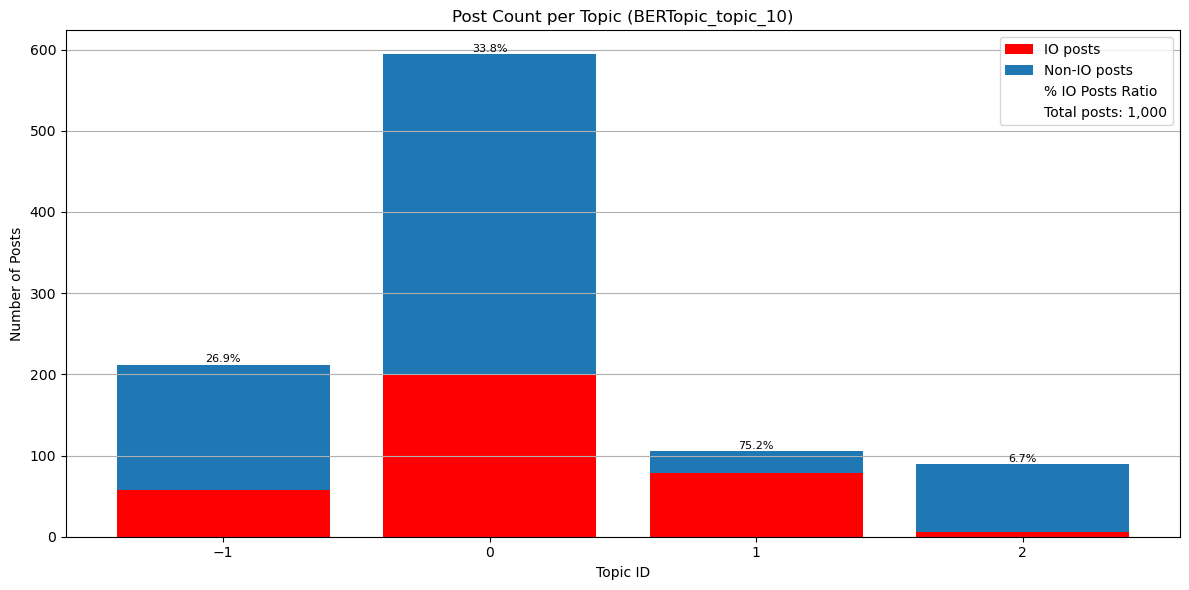

In [42]:
BERT_topic_stats = make_topic_stats(df, topic_col)
plot_topic_stats(BERT_topic_stats, topic_col, output_path)

Topic Account Statstistics

2026-07-21 15:34:26 | Completed: make_topic_account_stats


author_io_tag,BERTopic_topic_10,control_accounts,io_accounts,total_accounts,io_percent
0,-1,16,3,19,15.789474
1,0,18,3,21,14.285714
2,1,12,2,14,14.285714
3,2,9,1,10,10.000000


Plot saved to ../results/Labeled_Datasets/UAE/UAE_part_all/step_2_big_data_clustering/test/topic_col_BERTopic_topic_10/BERTopic_topic_10_topic_accounts.png


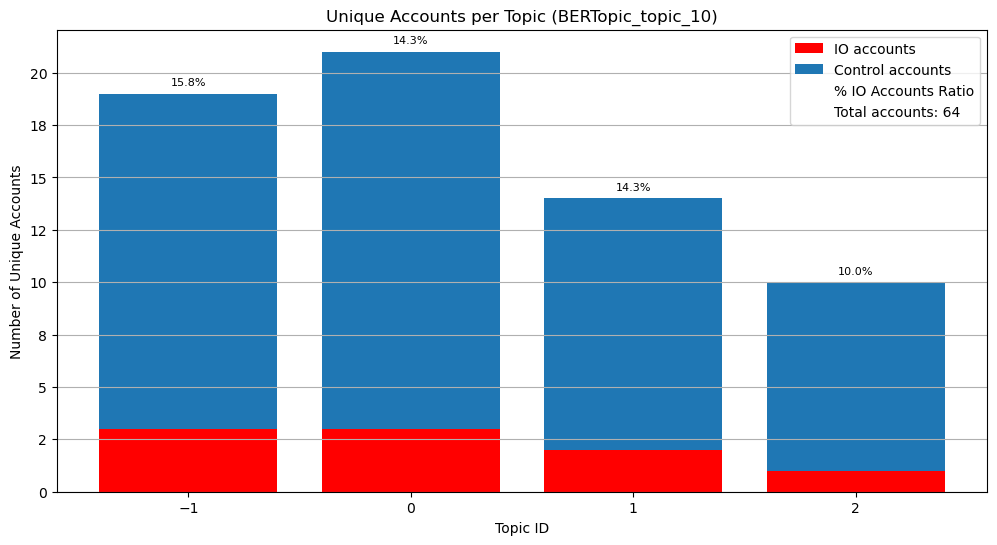

In [43]:
topic_account_stats = make_topic_account_stats(df, topic_col)
display(topic_account_stats)
plot_topic_account_stats(topic_account_stats, topic_col, output_path)

# K-Means

Stop before K-Means

In [44]:
# write_report("BERTopic Finished")
# write_report("Dont continue for k-means")
# sys.exit(0)

K Means is done by the `translate_topics_entities.ipynb`

In [45]:
# kmeans_topic_col_name = "K_Means_topic" # k value will be added to the collom

## Run K-Means

In [46]:
# @report_done
# def auto_kmeans_topics(embeddings, k_min=2**2, k_max=2**7, step = 4):
#     best_k = None
#     best_score = -1
#     best_labels = None

#     # print memory summary
#     # write_report(f"auto_kmeans_topics: \n {subprocess.check_output('nvidia-smi', shell=True).decode()}")

#     for k in range(k_min, k_max + 1, step):
#         print(f"Trying k={k}")
#         km = KMeans(n_clusters=k, random_state=42, n_init="auto")
#         labels = km.fit_predict(embeddings)
#         score = silhouette_score(embeddings, labels)

#         if score > best_score:
#             best_score = score
#             best_k = k
#             best_labels = labels

#     write_report(f"Best k for K-Means: {best_k} with silhouette score: {best_score:.4f}")

#     return best_labels, best_k

In [47]:
# labels, best_k = auto_kmeans_topics(embeddings, k_min=2**2, k_max=2**7)
# kmeans_topic_col_name = f"K_Means_topic_{best_k}"
# df[kmeans_topic_col_name] = labels
# write_report(f"k-means finished, best k {best_k}, topics saved to df in the column {kmeans_topic_col_name}")
# df.head()

## Graph and Statstistics

Topic Post Statistics

In [48]:
# topic_stats = make_topic_stats(df, kmeans_topic_col_name)
# plot_topic_stats(topic_stats, kmeans_topic_col_name, output_path)

Topic Account Statstistics

In [49]:
# topic_account_stats = make_topic_account_stats(df, kmeans_topic_col_name)
# plot_topic_account_stats(topic_account_stats, kmeans_topic_col_name, output_path)

## Save Model and df

In [50]:
# update_df_collumns_atomically(df, kmeans_topic_col_name)
# write_report("Saved df with BERTopic topics.")